# ⚛ ⚡️ Quantum formulation of energy network optimization




# ⚛ Problem representation in QUBO form

As in the single bus case, I constrain per-bus $k$ the value of the sum of in-flows to be the same as the demand $D_k$. 

We denote that as 

$
 P_k = \displaystyle\sum_{a \in powerplants at bus k} x_a
$

The difference now is that in addition to the Powerplant  production $P_k$ that feeds the bus,
there is also a potential in/out flow from a transmission line. 

This is denoted with $T_{i,j}$ to signify transmission from bus $i$ to bus $j$. The cost of transmission is $c_{i,j}$, and for simplicity was taken to increase linearly.

The in flow from a bus becomes the outflow from another bus to conserve the energy. 

In order to avoid many constraints and to have a bit-economical formulation, I use only one variable to parametrize the production of each line,
and as in the case of power plants, the maximum value is implicitly constrained by scaling down the max float value represented by the variable.

The objective then becomes:

$
H(T, P) = \lambda_i \displaystyle\sum_k (P_k - \displaystyle\sum_j T_{kj} + \displaystyle\sum_i T_{ik} - D_k)^2 + \displaystyle\sum_{i,j}  c_{i,j}T_{i,j} + \displaystyle\sum_\alpha c_a x_a 
$



# 👨‍💻 Code (network of busses)

In [2]:
from src.simple_powernetwork import EnergyNetwork, Line, Plant, DemandBus, VariablesIndex, NetworkExactSolver

In [9]:
VariablesIndex().reset_index()
plants = [
    Plant('plant 1', max_production=10, cost_per_unit = 8, num_bits=5),
    Plant('plant 2', max_production=7, cost_per_unit = 16, num_bits=5),
]

bus1 = DemandBus(plants=plants, demand=10)

plants = [
    Plant('plant 3', max_production=4, cost_per_unit = 8, num_bits=5)
]

bus2 = DemandBus(plants=plants, demand=10)

l = Line(name = 'line bus 1-> bus 2' , from_to = [bus1, bus2], line_cost=2, line_capacity=10, num_bits=5)
e = EnergyNetwork([bus1, bus2], [l])

In [10]:
# e._compute_offsets_for_lines()

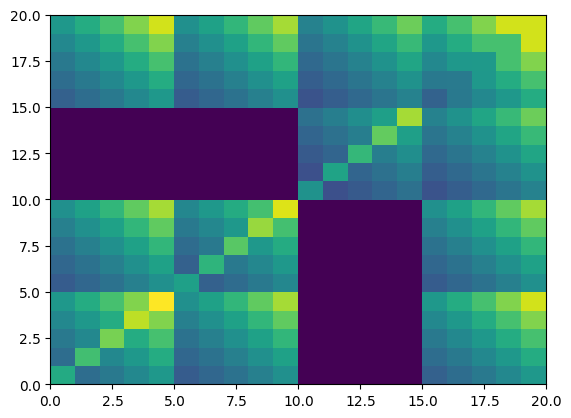

In [11]:
import numpy as np
import matplotlib.pyplot as pplot
pplot.pcolor(np.abs(e.create_qubo_matrix())**0.2)

In [13]:
# e.busses[0].number_sum.get_global_bit_inds()
# ni.all_number_index_offsets

In [14]:

nwe = NetworkExactSolver(e)
res = nwe.solve(lambda_val=10000)

In [17]:
e.busses

[<Bus (name : 9d0410ff9cc8ebdd1f1b2ee7191a1305 flows: -6.129032258064516 production: 16.129032258064516 demand: 10 n_plants: 2)>,
 <Bus (name : 8c6b2c595d6b4f7044798839874c3569 flows: 6.129032258064516 production: 3.870967741935484 demand: 10 n_plants: 1)>]

In [18]:
e.lines

[<Line (name : line bus 1-> bus 2, transfer: 6.129032258064516, line_capacity: 10, line_cost: 2)>]

In [21]:
for b in e.busses:
    
    for p in b.plants:
        print(p)
        print("---")

<Plant (name : plant 1, prod: 9.35483870967742, max_prod: 10, cost: 74.83870967741936)>
---
<Plant (name : plant 2, prod: 6.774193548387096, max_prod: 7, cost: 108.38709677419354)>
---
<Plant (name : plant 3, prod: 3.870967741935484, max_prod: 4, cost: 30.967741935483872)>
---
